
# 01 — Oracle Database: Queries & Exploration

The SDGFT Oracle Database contains **61.7 million** pre-computed parameter points
covering Δ ∈ [0.200, 0.220] × δ_g ∈ [0.040, 0.043], each with 37 GNN-predicted
observables and χ² scores against 21 experimental measurements.

This notebook shows how to:
1. Load and inspect the database
2. Run pandas queries and filters
3. Use DuckDB for SQL-style analytics
4. Export subsets for external tools

> **Oracle Database DOI:** [10.5281/zenodo.18863347](https://doi.org/10.5281/zenodo.18863347)

**See also:** [docs/oracle_schema.md](../docs/oracle_schema.md) for the full column reference.


In [1]:
from sdgft_ml.inference import OracleDB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

db = OracleDB()
print(db.summary())

/home/david/Coding/sdgft/sdgft-ml-toolkit/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SDGFT Oracle Database
  Rows:       61,701,488
  Columns:    44
  Δ range:    [0.204400, 0.216900]
  δ_g range:  [0.040000, 0.043000]
  Gold Std:   35,021,095
  Best χ²:    16.9696
  File:       /home/david/Coding/sdgft/sdgft-ml-toolkit/data/oracle_db.parquet
  Size:       3.41 GB


## 1. Basic Queries

In [2]:
# Column overview
print(f"Columns ({len(db.columns)}):")
for i, col in enumerate(db.columns):
    print(f"  {i:2d}. {col}", end="\n" if (i + 1) % 3 == 0 else "\t\t")
print()

Columns (44):
   0. delta		   1. delta_g		   2. d_star_tree
   3. d_star_fp		   4. n_tree		   5. n_fp
   6. alpha_m_tree		   7. alpha_b_tree		   8. eta_slip_survey
   9. eta_slip_horizon		  10. n_efolds_fp		  11. n_s
  12. r_tensor		  13. beta_iso		  14. epsilon_sr
  15. eta_sr		  16. omega_b		  17. omega_c
  18. omega_de		  19. omega_m		  20. w_de_fp
  21. eta_b		  22. s_8		  23. alpha_em_inv_tree
  24. alpha_em_inv_fp		  25. alpha_em_tree		  26. alpha_s
  27. sin2_theta_w		  28. mu_e_ratio		  29. tau_mu_ratio_tree
  30. lambda_geo		  31. higgs_mass		  32. n_generations
  33. theta_12		  34. theta_23		  35. theta_13
  36. v_us		  37. v_ub		  38. quark_hierarchy
  39. total_chi2		  40. chi2_per_dof		  41. n_tensions
  42. gold_standard		  43. desi_w_match		


In [3]:
# Best-fit points (lowest χ²)
top20 = db.best_fit(20)
display(top20[["delta", "delta_g", "total_chi2", "chi2_per_dof",
               "higgs_mass", "n_s", "omega_m", "sin2_theta_w", "alpha_s"]])

,delta,delta_g,total_chi2,chi2_per_dof,higgs_mass,n_s,omega_m,sin2_theta_w,alpha_s
30645391,0.210633,0.041865,16.969616,0.808077,125.630089,0.966434,0.316603,0.231167,0.117789
30655371,0.210635,0.041859,16.969616,0.808077,125.630684,0.966434,0.316609,0.231167,0.117789
30655381,0.210635,0.041862,16.969616,0.808077,125.630684,0.966434,0.316609,0.231167,0.117789
30655383,0.210635,0.041863,16.969618,0.808077,125.630684,0.966434,0.316609,0.231167,0.117789
30655368,0.210635,0.041858,16.969620,0.808077,125.630684,0.966435,0.316609,0.231167,0.117789
30655379,0.210635,0.041861,16.969620,0.808077,125.630684,0.966434,0.316609,0.231167,0.117789
30655380,0.210635,0.041862,16.969622,0.808077,125.630684,0.966434,0.316609,0.231167,0.117789
30645389,0.210633,0.041864,16.969624,0.808077,125.630089,0.966434,0.316603,0.231167,0.117789
30645390,0.210633,0.041865,16.969624,0.808077,125.630089,0.966434,0.316603,0.231167,0.117789
30655362,0.210635,0.041856,16.969624,0.808077,125.630684,0.966435,0.316609,0.231167,0.117789


In [4]:
# Filter by observable range — Higgs mass within 2σ of experiment
higgs_range = db.filter_observable("higgs_mass", 124.91, 125.59)  # 125.25 ± 2×0.17
print(f"Points with m_H ∈ [124.91, 125.59] GeV: {len(higgs_range):,}")
print(f"Best χ² in this subset: {higgs_range['total_chi2'].min():.2f}")

Points with m_H ∈ [124.91, 125.59] GeV: 11,399,370
Best χ² in this subset: 16.98


In [5]:
# Compound query with pandas expression
tight = db.query(
    "higgs_mass > 124.5 and higgs_mass < 126.0 "
    "and n_s > 0.96 and n_s < 0.97 "
    "and chi2_per_dof < 1.5"
)
print(f"Points passing tight cuts: {len(tight):,}")
tight[["delta", "delta_g", "total_chi2", "higgs_mass", "n_s"]].describe()

Points passing tight cuts: 25,143,500


,delta,delta_g,total_chi2,higgs_mass,n_s
count,2.514350e+07,2.514350e+07,2.514350e+07,2.514350e+07,2.514350e+07
mean,2.093634e-01,4.149991e-02,1.969629e+01,1.252513e+02,9.668225e-01
std,1.451806e-03,8.660964e-04,2.777245e+00,4.329857e-01,3.993897e-04
min,2.068487e-01,4.000000e-02,1.696962e+01,1.245000e+02,9.659028e-01
25%,2.081068e-01,4.074977e-02,1.750615e+01,1.248765e+02,9.665077e-01
50%,2.093629e-01,4.149985e-02,1.837028e+01,1.252520e+02,9.668241e-01
75%,2.106211e-01,4.224993e-02,2.148521e+01,1.256265e+02,9.671392e-01
max,2.118772e-01,4.300000e-02,2.801338e+01,1.260000e+02,9.677306e-01


## 2. Gold Standard Subset

The Gold Standard contains all points with χ²/dof < 1.2 — about 35M rows.

In [6]:
gold = db.gold_standard()
print(f"Gold Standard rows: {len(gold):,}")
print(f"χ²/dof range: [{gold['chi2_per_dof'].min():.4f}, {gold['chi2_per_dof'].max():.4f}]")
print(f"\nParameter ranges in Gold:")
for col in ["delta", "delta_g"]:
    print(f"  {col}: [{gold[col].min():.6f}, {gold[col].max():.6f}]")

Gold Standard rows: 35,021,095
χ²/dof range: [0.8081, 1.2000]

Parameter ranges in Gold:
  delta: [0.207057, 0.214225]
  delta_g: [0.040000, 0.043000]


## 3. Statistical Profiles

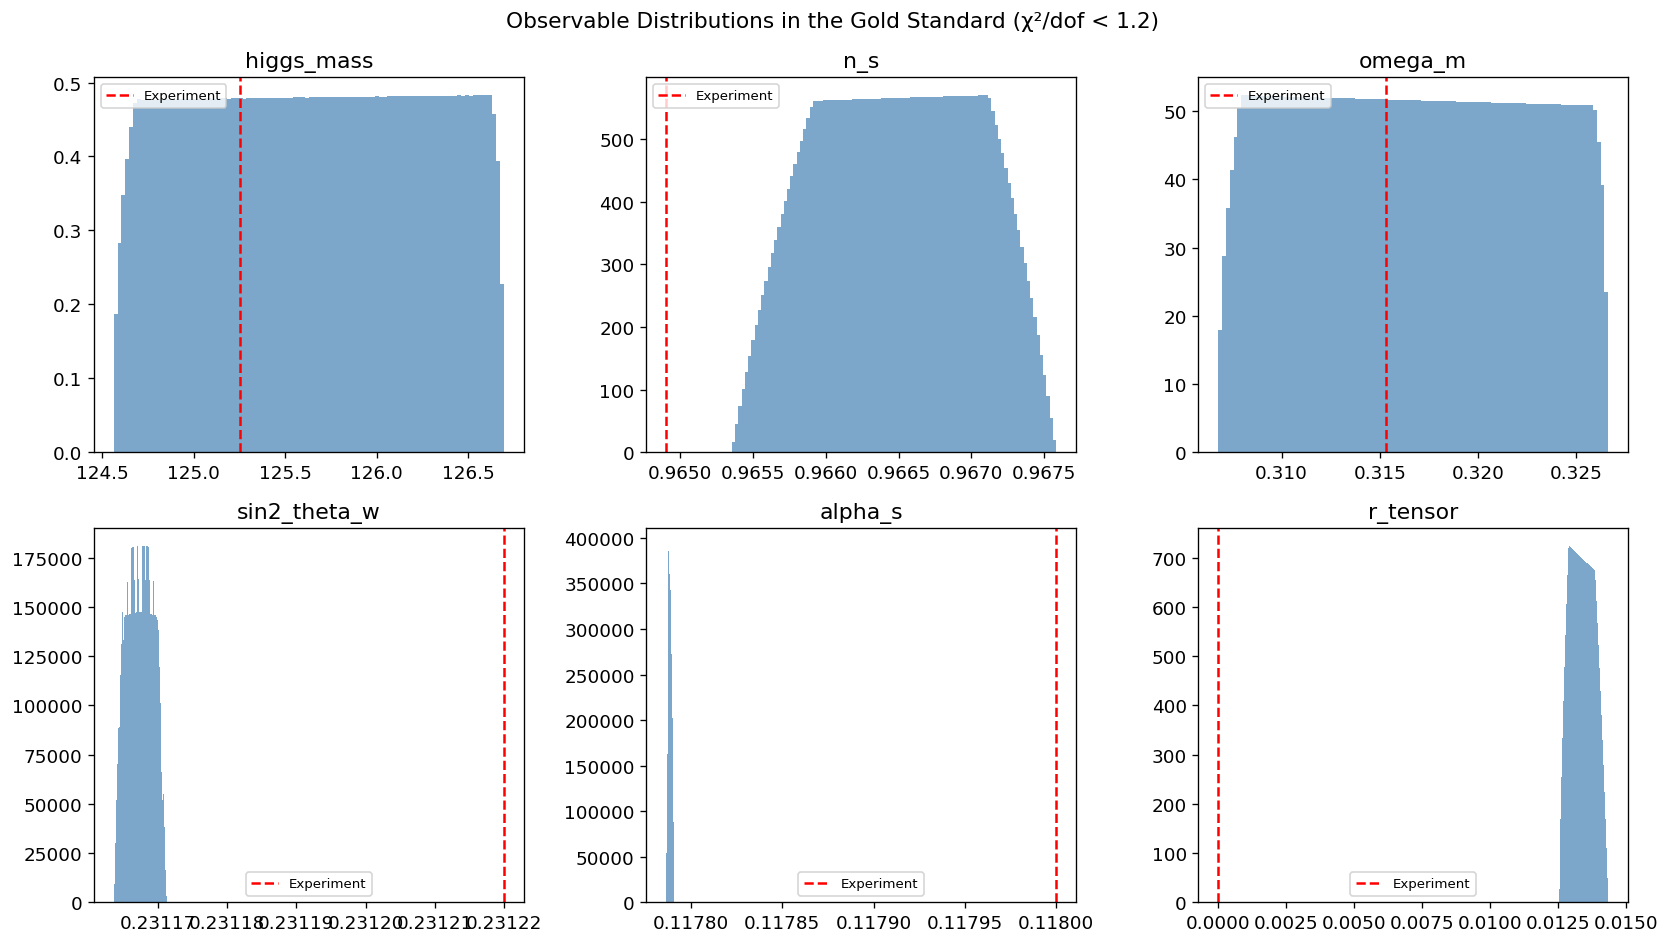

In [7]:
# Distribution of key observables in the Gold Standard
obs_highlight = ["higgs_mass", "n_s", "omega_m", "sin2_theta_w", "alpha_s", "r_tensor"]
exp_values = {
    "higgs_mass": 125.25, "n_s": 0.9649, "omega_m": 0.3153,
    "sin2_theta_w": 0.23122, "alpha_s": 0.1180, "r_tensor": 0.0,
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, obs in zip(axes.flat, obs_highlight):
    vals = gold[obs].values
    ax.hist(vals, bins=100, alpha=0.7, color="steelblue", density=True)
    if obs in exp_values:
        ax.axvline(exp_values[obs], color="red", ls="--", lw=1.5, label="Experiment")
    ax.set_title(obs)
    ax.legend(fontsize=8)

fig.suptitle("Observable Distributions in the Gold Standard (χ²/dof < 1.2)", fontsize=13)
plt.tight_layout()
plt.show()

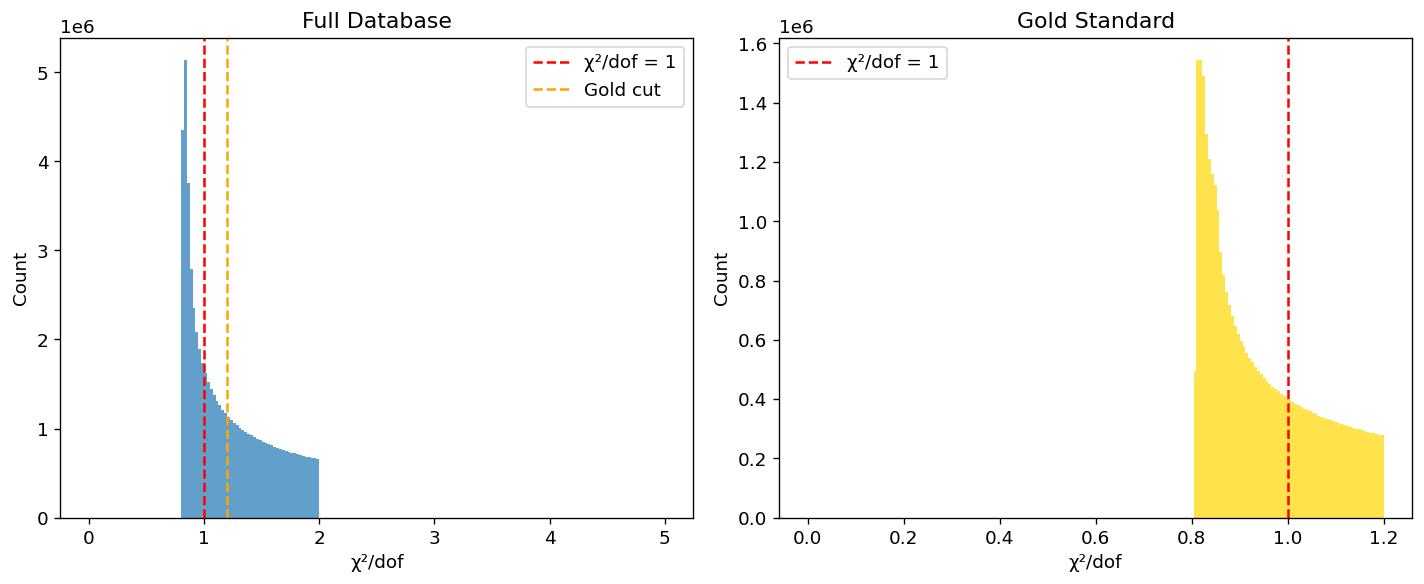

In [8]:
# χ² distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Full database
ax1.hist(db.df["chi2_per_dof"].values, bins=200, range=(0, 5), alpha=0.7)
ax1.set_xlabel("χ²/dof")
ax1.set_ylabel("Count")
ax1.set_title("Full Database")
ax1.axvline(1.0, color="red", ls="--", label="χ²/dof = 1")
ax1.axvline(1.2, color="orange", ls="--", label="Gold cut")
ax1.legend()

# Gold zoom
ax2.hist(gold["chi2_per_dof"].values, bins=200, range=(0, 1.2), alpha=0.7, color="gold")
ax2.set_xlabel("χ²/dof")
ax2.set_ylabel("Count")
ax2.set_title("Gold Standard")
ax2.axvline(1.0, color="red", ls="--", label="χ²/dof = 1")
ax2.legend()

plt.tight_layout()
plt.show()

## 4. DuckDB SQL Analytics (Optional)

For complex aggregations, DuckDB can query Parquet files directly
without loading them into memory.

Install: `pip install duckdb`

In [12]:
try:
    import duckdb

    parquet_path = str(db.parquet_path)

    # Binned statistics: mean Higgs mass by Δ bin
    result = duckdb.sql(f"""
        SELECT
            round(delta, 4) AS delta_bin,
            count(*) AS n,
            avg(higgs_mass) AS avg_higgs,
            min(total_chi2) AS min_chi2,
            avg(chi2_per_dof) AS avg_chi2_dof
        FROM read_parquet('{parquet_path}')
        WHERE chi2_per_dof < 1.5
        GROUP BY delta_bin
        ORDER BY delta_bin
        LIMIT 30
    """)
    display(result.df())

except ImportError:
    print("DuckDB not installed — skipping SQL examples.")
    print("Install with: pip install duckdb")

,delta_bin,n,avg_higgs,min_chi2,avg_chi2_dof
0,0.2059,120032,124.221090,31.087753,1.491594
1,0.2060,309158,124.245816,30.490597,1.475193
2,0.2061,408944,124.275512,29.906502,1.456034
3,0.2062,483100,124.305375,29.335201,1.436782
4,0.2063,500000,124.335147,28.776894,1.411677
5,0.2064,500000,124.365185,28.231548,1.384840
6,0.2065,500000,124.395215,27.699116,1.358627
7,0.2066,500000,124.425238,27.179729,1.333039
8,0.2067,500000,124.455254,26.673172,1.308076
9,0.2068,500000,124.485261,26.179621,1.283736


In [13]:
try:
    import duckdb

    # Correlation query: which observables correlate most with χ²?
    obs_cols = [c for c in db.columns if c not in (
        "delta", "delta_g", "total_chi2", "chi2_per_dof",
        "n_tensions", "gold_standard", "desi_w_match"
    )]

    corr_sql = ", ".join([f"corr({col}, total_chi2) AS corr_{col}" for col in obs_cols[:10]])
    result = duckdb.sql(f"""
        SELECT {corr_sql}
        FROM read_parquet('{parquet_path}')
    """)
    corr_df = result.df().T
    corr_df.columns = ["corr_with_chi2"]
    corr_df.index = [c.replace("corr_", "") for c in corr_df.index]
    display(corr_df.sort_values("corr_with_chi2", key=abs, ascending=False))

except ImportError:
    pass

,corr_with_chi2
eta_slip_survey,0.029992
n_efolds_fp,0.018243
eta_slip_horizon,0.015802
alpha_b_tree,0.015794
alpha_m_tree,-0.015778
n_tree,-0.015767
d_star_tree,-0.015764
n_s,-0.005324
n_fp,0.004479
d_star_fp,0.004370


## 5. Export Subsets

In [14]:
# Export a filtered subset to CSV
subset = db.query("chi2_per_dof < 1.0")[["delta", "delta_g", "total_chi2",
                                           "higgs_mass", "n_s", "omega_m"]]
print(f"Exporting {len(subset):,} rows with χ²/dof < 1.0")

# Uncomment to save:
# subset.to_csv("oracle_subset_chi2lt1.csv", index=False)
# subset.to_parquet("oracle_subset_chi2lt1.parquet", index=False)

subset.head(10)

Exporting 24,097,684 rows with χ²/dof < 1.0


,delta,delta_g,total_chi2,higgs_mass,n_s,omega_m
18136584,0.208131,0.042223,20.999983,124.883797,0.966998,0.309705
18136585,0.208131,0.042223,20.999943,124.883797,0.966998,0.309705
18136586,0.208131,0.042224,20.999954,124.883797,0.966998,0.309705
18136587,0.208131,0.042224,20.999924,124.883797,0.966998,0.309705
18136588,0.208131,0.042224,20.999912,124.883797,0.966997,0.309705
18136589,0.208131,0.042224,20.999889,124.883797,0.966997,0.309705
18136590,0.208131,0.042225,20.999866,124.883797,0.966997,0.309705
18136591,0.208131,0.042225,20.999832,124.883797,0.966997,0.309705
18136592,0.208131,0.042225,20.999805,124.883797,0.966997,0.309705
18136593,0.208131,0.042226,20.999805,124.883797,0.966997,0.309705


---

**Next:** [02 Parameter Landscape](02_parameter_landscape.ipynb) — Sensitivity maps and correlation analysis